<a href="https://colab.research.google.com/github/VancuraFlow/MLDocs/blob/main/autoencoder/cx-autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Autoencoders: Teaching Machines to Compress and Reconstruct

In-Class Exercise

---

## The Big Picture: What Is an Autoencoder?

Imagine you work at a company that needs to send large reports across a slow network every day. To save bandwidth, you hire two specialists:

- **The Compressor** (Encoder): reads the full report and distills it into a one-page summary, capturing only the essential information.
- **The Reconstructor** (Decoder): takes that one-page summary and re-expands it back into a full (approximate) report.

The better this pair gets at their jobs, the more your company can confidently compress-and-reconstruct with minimal loss of information.

**An autoencoder is exactly this.** It is a neural network trained to compress data into a small "bottleneck" representation (called the **latent space**), and then reconstruct the original data from it. The magic is that no human labels are needed: the network teaches itself.

---

### 🗺️ What We'll Do Today

1. **Explore the dataset**: What does our data look like?
2. **Train a classic autoencoder**: Can it reconstruct images faithfully?
3. **Reconstruction quality per digit**: Where does the compression hurt most?
4. **Visualize the latent space**: What does the "summary" look like?
5. **Introduce noise**: What happens when the input is corrupted?
6. **Train a denoising autoencoder**: Can we teach it to clean up noisy images?
7. **Head-to-head comparison**: Classic against denoising.
8. **Real-world business applications**: Where is this being used right now?
9. ⭐ **BONUS: PCA Denoising**: A classic alternative, for those who want a challenge.

In [1]:
#@title 🗺️ Roadmap (double-click to view the code) { display-mode: "form" }
from IPython.display import HTML, display

_STEPS = [
    ("1", "The documents", "70,000 handwritten digits", "#667eea", "#764ba2"),
    ("2", "Compress", "784 numbers down to 16", "#764ba2", "#e0796d"),
    ("3", "The summary", "inside the latent space", "#e0796d", "#e0a23c"),
    ("4", "Noisy input", "what corruption does to it", "#e0a23c", "#39b36a"),
    ("5", "Denoise", "training it to clean up", "#39b36a", "#667eea"),
]


def _roadmap_html(steps):
    cards = []
    for num, title, sub, c1, c2 in steps:
        cards.append(f"""
        <div style="flex: 1 1 150px; min-width: 140px; background: #fff;
                    border: 1px solid #e6e8ee; border-radius: 14px;
                    padding: 14px 12px; text-align: center;">
          <div style="width: 42px; height: 42px; margin: 0 auto 10px;
                      border-radius: 50%; display: flex; align-items: center;
                      justify-content: center; color: #fff; font-weight: 700;
                      font-size: 1.05rem;
                      background: linear-gradient(135deg, {c1}, {c2});">{num}</div>
          <div style="font-weight: 650; color: #23262f; font-size: .95rem;">{title}</div>
          <div style="color: #6b7280; font-size: .8rem; margin-top: 4px;">{sub}</div>
        </div>""")
    return f"""
    <div style="font-family: system-ui, Segoe UI, Roboto, sans-serif;
                border-radius: 18px; border: 1px solid #ecebff; padding: 18px;
                background: linear-gradient(135deg, #f6f8ff, #fbf5ff);">
      <div style="font-size: .78rem; letter-spacing: .14em; text-transform: uppercase;
                  color: #764ba2; margin-bottom: 12px;">
        compress, reconstruct, corrupt, repair
      </div>
      <div style="display: flex; flex-wrap: wrap; gap: 10px;">{''.join(cards)}</div>
    </div>"""


display(HTML(_roadmap_html(_STEPS)))

In [2]:
#@title ⚙️ Setup (double-click to view the code) { display-mode: "form" }
import warnings
warnings.filterwarnings("ignore")

UTILS_SRC = r'''
"""Support code for the autoencoders coding exercise.

Everything in here is plumbing: data plumbing, the evaluation classifier's
training loop, the figures, and the PASS / NOT YET checks. None of it is a
task. The five things participants write live in the notebook itself, in the
cells marked with a target emoji.

The notebook inlines this file (see build_notebooks.py), so it must stay
importable with nothing but torch, numpy, matplotlib and scikit-learn, and it
must stay free of the dash characters the house style forbids.
"""

import contextlib
import functools
import io

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ── Device and reproducibility ────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── House palette ─────────────────────────────────────────────────────────────
PURPLE, PURPLE2 = '#667eea', '#764ba2'          # primary, gradient accent
GREEN, RED, AMBER = '#39b36a', '#e0796d', '#e0a23c'   # good, bad, caution

# Batch size used whenever a whole split is pushed through a network for
# evaluation. Sending all 10000 test images at once builds about a gigabyte of
# convolution activations, which is fine on a T4 and not fine on a small CPU
# runtime.
EVAL_BATCH = 512


def setup():
    """Apply the house plot style and report the device. Call once."""
    plt.rcParams['figure.dpi'] = 110
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    print("Setup complete. Running on:", DEVICE)
    if DEVICE.type != "cuda":
        print("No GPU found. Runtime > Change runtime type > T4 GPU makes training much faster.")


# ── PASS / NOT YET checks ─────────────────────────────────────────────────────

def check(name, ok, detail=""):
    """Print one PASS or NOT YET line. Returns the boolean, so checks can be
    combined with `all([...])`.

    Args:
        name: what is being checked, in plain words.
        ok: the result of the test.
        detail: shown only on failure, to say what went wrong.
    """
    ok = bool(ok)
    print(("PASS     " if ok else "NOT YET  ") + name)
    if not ok and detail:
        print("         " + detail)
    return ok


def _guarded(label):
    """Turn any exception inside a check into a NOT YET line.

    A participant who has not filled in an earlier task should see one honest
    NOT YET, not a traceback out of the checking code itself.
    """
    def decorate(fn):
        @functools.wraps(fn)
        def wrapper(*args, **kwargs):
            try:
                return fn(*args, **kwargs)
            except Exception as exc:
                return check(label, False, "{}: {}".format(type(exc).__name__, exc))
        return wrapper
    return decorate


@_guarded("the autoencoder runs")
def check_autoencoder_shapes(model):
    """Task 1. Run four random images through encode, decode and forward.

    Catches every common slip (a missing flatten, the wrong view, a forward
    that returns the latent vector) in under a second, on an untrained model,
    before anybody waits on a training run.
    """
    model.eval()
    # Read the bottleneck size off the layer itself, so the notebook can keep
    # the literal 128 in its architecture without a constant to keep in step.
    latent_dim = model.encoder_fc.out_features
    x = torch.rand(4, 1, 28, 28, device=DEVICE)
    results = []
    try:
        with torch.no_grad():
            z = model.encode(x)
    except Exception as exc:
        return check("encode() runs", False, "{}: {}".format(type(exc).__name__, exc))
    results.append(check(
        "encode() turns 4 images into 4 latent vectors of {} numbers".format(latent_dim),
        tuple(z.shape) == (4, latent_dim),
        "got {}, expected (4, {})".format(tuple(z.shape), latent_dim)))

    try:
        with torch.no_grad():
            out = model.decode(z)
    except Exception as exc:
        results.append(check("decode() runs", False, "{}: {}".format(type(exc).__name__, exc)))
        return all(results)
    results.append(check(
        "decode() turns those back into 4 images of 1x28x28",
        tuple(out.shape) == (4, 1, 28, 28),
        "got {}, expected (4, 1, 28, 28)".format(tuple(out.shape))))

    try:
        with torch.no_grad():
            full = model(x)
    except Exception as exc:
        results.append(check("forward() runs", False, "{}: {}".format(type(exc).__name__, exc)))
        return all(results)
    results.append(check(
        "forward() gives back something the same shape as its input",
        tuple(full.shape) == tuple(x.shape),
        "got {}, expected {}".format(tuple(full.shape), tuple(x.shape))))
    results.append(check(
        "the output pixels are in [0, 1], like the input",
        0.0 <= float(full.min()) and float(full.max()) <= 1.0,
        "range is [{:.3f}, {:.3f}]".format(float(full.min()), float(full.max()))))
    return all(results)


@_guarded("the training loop runs")
def check_training_step(train_fn, model_cls, X_np, n=512):
    """Task 2. Train a throwaway copy on a few hundred images and see whether
    the loss actually fell and the weights actually moved.

    An `opt.step()` that never runs leaves both unchanged, which is exactly the
    mistake this catches, in seconds rather than at the end of 25 epochs.

    Args:
        train_fn: the participant's train_autoencoder.
        model_cls: the autoencoder class, so the probe is a fresh model.
        X_np: training images, shape (N, 28, 28).
        n: how many of them the probe trains on.

    Returns:
        True when every line printed PASS.
    """
    probe = model_cls().to(DEVICE)
    before = [p.detach().clone() for p in probe.parameters()]
    sample = torch.tensor(X_np[:n, None, :, :]).to(DEVICE)
    loss_fn = nn.MSELoss()

    probe.eval()
    with torch.no_grad():
        start = float(loss_fn(probe(sample), sample))

    try:
        with contextlib.redirect_stdout(io.StringIO()):   # the probe's epoch log
            probe = train_fn(probe, X_np[:n], epochs=3, batch_size=64)
    except Exception as exc:
        return check("the training loop runs", False,
                     "{}: {}".format(type(exc).__name__, exc))

    moved = any(not torch.equal(a, b.detach()) for a, b in zip(before, probe.parameters()))
    ok_moved = check("the optimizer actually updated the weights", moved,
                     "the weights are unchanged, so opt.step() never ran")

    probe.eval()
    with torch.no_grad():
        end = float(loss_fn(probe(sample), sample))
    ok_loss = check("three epochs on {} images brought the loss down".format(n),
                    end < 0.6 * start,
                    "loss went from {:.4f} to {:.4f}, which is not a real drop".format(start, end))
    return ok_moved and ok_loss


@_guarded("reconstruct() runs")
def check_reconstruct(reconstruct_fn, model, X_np):
    """Task 3. Shape, dtype and range of the inference helper's output."""
    try:
        out = reconstruct_fn(model, X_np[:16])
    except Exception as exc:
        return check("reconstruct() runs", False, "{}: {}".format(type(exc).__name__, exc))
    results = [
        check("reconstruct() returns a numpy array",
              isinstance(out, np.ndarray), "got a {}".format(type(out).__name__)),
        check("it has one 28x28 image per input image",
              getattr(out, "shape", None) == (16, 28, 28),
              "got {}, expected (16, 28, 28)".format(getattr(out, "shape", None))),
    ]
    if isinstance(out, np.ndarray) and out.size:
        results.append(check("the pixels are in [0, 1]",
                             0.0 <= float(out.min()) and float(out.max()) <= 1.0,
                             "range is [{:.3f}, {:.3f}]".format(float(out.min()), float(out.max()))))
    return all(results)


@_guarded("add_noise() runs")
def check_add_noise(add_noise_fn, X_np):
    """Task 4. Range, shape, dtype, reproducibility, and that the noise scales."""
    try:
        noisy = add_noise_fn(X_np[:200], noise_factor=0.3, seed=0)
    except Exception as exc:
        return check("add_noise() runs", False, "{}: {}".format(type(exc).__name__, exc))
    results = [
        check("the noisy images have the same shape as the clean ones",
              getattr(noisy, "shape", None) == X_np[:200].shape,
              "got {}, expected {}".format(getattr(noisy, "shape", None), X_np[:200].shape)),
        check("they are float32, which is what torch expects",
              getattr(noisy, "dtype", None) == np.float32,
              "got {}".format(getattr(noisy, "dtype", None))),
    ]
    if not isinstance(noisy, np.ndarray) or noisy.shape != X_np[:200].shape:
        return False
    results.append(check("the pixels were clipped back into [0, 1]",
                         0.0 <= float(noisy.min()) and float(noisy.max()) <= 1.0,
                         "range is [{:.3f}, {:.3f}]".format(float(noisy.min()), float(noisy.max()))))
    results.append(check("the noise actually changed the images",
                         not np.allclose(noisy, X_np[:200]),
                         "the output is identical to the input"))
    results.append(check("the same seed gives the same noise twice",
                         np.array_equal(noisy, add_noise_fn(X_np[:200], noise_factor=0.3, seed=0)),
                         "two calls with seed=0 disagreed"))
    louder = add_noise_fn(X_np[:200], noise_factor=0.9, seed=0)
    results.append(check("a bigger noise_factor makes a noisier image",
                         np.abs(louder - X_np[:200]).mean() > np.abs(noisy - X_np[:200]).mean(),
                         "noise_factor=0.9 was no louder than noise_factor=0.3"))
    return all(results)


@_guarded("the two arrays are usable")
def check_denoising_pair(target, inputs, clean, noisy):
    """Task 5. The two arrays handed to the denoising training run.

    Swapping them trains clean to noisy, which looks plausible for twenty
    epochs and then produces a model that adds noise. Checked before training,
    not after.
    """
    return all([
        check("the TARGET is the clean training images",
              isinstance(target, np.ndarray) and target.shape == clean.shape
              and np.array_equal(target, clean),
              "X_train_np must be the clean images"),
        check("the INPUT is the noisy training images",
              isinstance(inputs, np.ndarray) and inputs.shape == noisy.shape
              and np.array_equal(inputs, noisy),
              "X_input_np must be the noisy images"),
    ])


@_guarded("the PCA reconstruction is usable")
def check_pca_denoising(recon_pca, X_test_noisy, X_test):
    """Bonus. Shape and range of the PCA reconstruction, and that it helped."""
    if getattr(recon_pca, "shape", None) != X_test_noisy.shape:
        return check("one denoised 28x28 image per noisy test image", False,
                     "got {}, expected {}".format(getattr(recon_pca, "shape", None),
                                                  X_test_noisy.shape))
    before = float(np.mean((X_test_noisy - X_test) ** 2))
    after = float(np.mean((recon_pca - X_test) ** 2))
    return all([
        check("one denoised 28x28 image per noisy test image", True),
        check("the pixels were clipped back into [0, 1]",
              0.0 <= float(recon_pca.min()) and float(recon_pca.max()) <= 1.0,
              "range is [{:.3f}, {:.3f}]".format(float(recon_pca.min()),
                                                 float(recon_pca.max()))),
        check("the result is closer to the clean images than the noisy input was",
              after < before,
              "MSE against clean went from {:.5f} to {:.5f}".format(before, after)),
    ])


# ── The evaluation classifier ─────────────────────────────────────────────────

def train_classifier(model_cls, X_np, y_np, epochs=10, batch_size=256):
    """Train the digit classifier used to score reconstructions.

    Args:
        model_cls: the classifier class, for example MNISTClassifier.
        X_np: images, shape (N, 28, 28).
        y_np: integer labels, shape (N,).
        epochs: passes over the data.
        batch_size: mini batch size.

    Returns:
        The trained model, in whatever mode the last epoch left it.
    """
    model = model_cls().to(DEVICE)
    X_t = torch.tensor(X_np[:, None, :, :]).to(DEVICE)
    y_t = torch.tensor(y_np, dtype=torch.long).to(DEVICE)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for _ in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss_fn(model(xb), yb).backward()
            opt.step()
    return model


def predict_digits(classifier, X_np, batch_size=EVAL_BATCH):
    """Classify images in batches and return the predicted labels.

    Args:
        classifier: a trained MNISTClassifier.
        X_np: images, shape (N, 28, 28).
        batch_size: how many images to send to the network at a time.

    Returns:
        Predicted labels, shape (N,).
    """
    classifier.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch_size):
            xb = torch.tensor(X_np[i:i + batch_size, None, :, :]).to(DEVICE)
            preds.append(classifier(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds) if preds else np.empty(0, dtype=int)


def evaluate_and_plot_confusion(classifier, X_np, y_true, title="Confusion Matrix"):
    """Classify X_np, print the accuracy and draw the confusion matrix.

    Args:
        classifier: a trained MNISTClassifier.
        X_np: images to score, shape (N, 28, 28).
        y_true: their true labels, shape (N,).
        title: figure title.

    Returns:
        The accuracy, as a float in [0, 1].
    """
    preds = predict_digits(classifier, X_np)
    acc = accuracy_score(y_true, preds)
    print("  Accuracy: {:.2%}".format(acc))

    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay(confusion_matrix(y_true, preds)).plot(ax=ax, colorbar=False)
    ax.set_title("{}  (acc = {:.2%})".format(title, acc), fontsize=12)
    plt.tight_layout()
    plt.show()
    return acc


# ── Figures ───────────────────────────────────────────────────────────────────

def style_image_grid(axes, row_labels=None):
    """Tidy a grid of image axes, keeping the left column's row labels visible.

    `ax.axis('off')` switches the whole axis off, row labels included, so the
    labels never render. Here every axis keeps its ticks and spines hidden
    instead, which looks identical but lets the first column show its ylabel.

    Args:
        axes: 2-D array of matplotlib axes, shape (n_rows, n_cols).
        row_labels: optional labels, one per row, drawn on the first column.
    """
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes[None, :]
    for r in range(axes.shape[0]):
        for c in range(axes.shape[1]):
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])
            for spine in axes[r, c].spines.values():
                spine.set_visible(False)
        if row_labels is not None and r < len(row_labels):
            axes[r, 0].set_ylabel(row_labels[r], fontsize=10)


def plot_image_pair(top, bottom, n=8, title="", row_labels=("Original", "Reconstructed")):
    """Two rows of images with a label on each row.

    Args:
        top: images for the top row, shape (N, 28, 28).
        bottom: images for the bottom row, shape (N, 28, 28).
        n: how many columns to show.
        title: figure title.
        row_labels: the two row labels. Pass them whenever the rows are not
            an original and its reconstruction, so the labels stay honest.
    """
    n = min(n, len(top), len(bottom))
    fig, axes = plt.subplots(2, n, figsize=(2 * n, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i in range(n):
        axes[0, i].imshow(top[i], cmap='gray')
        axes[1, i].imshow(bottom[i], cmap='gray')
    style_image_grid(axes, list(row_labels))
    plt.tight_layout()
    plt.show()


def plot_original_vs_reconstructed(original, reconstructed, n=8,
                                   title="Original vs. Reconstructed",
                                   row_labels=("Original", "Reconstructed")):
    """Originals on top, reconstructions below. See plot_image_pair."""
    plot_image_pair(original, reconstructed, n=n, title=title, row_labels=row_labels)
'''

MODELS_SRC = r'''
import torch
import torch.nn as nn

class MNISTClassifier(nn.Module):
    """Simple CNN classifier used to evaluate reconstruction quality."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64*7*7, 128), nn.ReLU(), nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
'''

DATA_SRC = r'''
import numpy as np
from torchvision import datasets, transforms


def load_mnist():
    """
    Downloads and returns MNIST as numpy float32 arrays normalised to [0, 1].

    Returns
    -------
    X_train, y_train, X_test, y_test
        Images are shape (N, 28, 28); labels are shape (N,).
    """
    transform = transforms.ToTensor()
    train_data = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
    test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    X_train = train_data.data.numpy().astype("float32") / 255.0
    y_train = train_data.targets.numpy()
    X_test  = test_data.data.numpy().astype("float32") / 255.0
    y_test  = test_data.targets.numpy()

    print(f"Training images : {X_train.shape}  → {len(X_train):,} images of 28×28 pixels")
    print(f"Test images     : {X_test.shape}   → {len(X_test):,} images of 28×28 pixels")
    print(f"Digit classes   : {np.unique(y_train)}")

    return X_train, y_train, X_test, y_test
'''

EXTRA_SRC = r'''
"""Extra figures for the _sanziana variant of the autoencoders exercise.

This module is additive. It holds only what the variant needs on top of
`utils.py`, so the original exercise keeps exactly the support code it had.

Two figures live here:

- `plot_compression_triplet` puts the latent code between the input and the
  output, so the bottleneck is something a participant can see rather than a
  number in the prose. Without it, input and output look identical and the
  obvious question is why anyone would want a machine that copies its input.
- `plot_reconstruction_error` adds an absolute-error row, so "digit 8 has the
  highest MSE" is visible on the image instead of being taken on trust.
"""

import random

import numpy as np
import matplotlib.pyplot as plt
import torch

from utils import style_image_grid


def set_seed(seed=42):
    """Make whatever the next cell does reproducible, whatever ran before it.

    Cells get run out of order and re-run, and every model built and every
    batch shuffled draws from the same global generators. Without this, a
    participant who runs the check cell twice trains a different model from
    everybody else, and the numbers the prose quotes stop matching the numbers
    on screen.

    Determinism holds within a device type. A GPU run and a CPU run still
    differ from each other, and so do two different GPUs.

    Args:
        seed: the seed applied to random, numpy and torch.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _latent_grid(vec):
    """Lay a latent vector out as the squarest grid that holds it.

    Args:
        vec: one latent vector, shape (D,).

    Returns:
        A 2-D array, padded with the vector's mean when D is not a square.
    """
    d = int(vec.shape[0])
    side = int(np.ceil(np.sqrt(d)))
    out = np.full(side * side, float(vec.mean()), dtype="float32")
    out[:d] = vec
    return out.reshape(side, side)


def plot_compression_triplet(original, latent, reconstructed, n=8,
                             title="Down to the summary and back"):
    """Three rows: the input, the latent code it was squeezed to, the output.

    The middle row is drawn short on purpose. A 4x4 patch of colour beside a
    28x28 image is the whole argument: that patch is everything that crosses
    the network.

    Args:
        original: images in, shape (N, 28, 28).
        latent: the codes, shape (N, D).
        reconstructed: images out, shape (N, 28, 28).
        n: how many columns to show.
        title: figure title.
    """
    n = min(n, len(original), len(latent), len(reconstructed))
    pixels = int(np.prod(original.shape[1:]))
    dim = int(latent.shape[1])

    fig, axes = plt.subplots(3, n, figsize=(2 * n, 5.8),
                             gridspec_kw={"height_ratios": [3, 1.3, 3]})
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i in range(n):
        axes[0, i].imshow(original[i], cmap='gray')
        axes[1, i].imshow(_latent_grid(latent[i]), cmap='viridis')
        axes[2, i].imshow(reconstructed[i], cmap='gray')
    style_image_grid(axes, [
        "{} numbers\nin".format(pixels),
        "{} numbers\nthe summary".format(dim),
        "{} numbers\nout".format(pixels),
    ])
    plt.tight_layout()
    plt.show()


def plot_reconstruction_error(original, reconstructed, n=5,
                              title="Where the error actually is"):
    """Original, reconstruction, and the absolute difference between them.

    Args:
        original: clean images, shape (N, 28, 28).
        reconstructed: the autoencoder's output, same shape.
        n: how many columns to show.
        title: figure title.
    """
    n = min(n, len(original), len(reconstructed))
    err = np.abs(original[:n].astype("float32") - reconstructed[:n].astype("float32"))

    fig, axes = plt.subplots(3, n, figsize=(2.1 * n, 6.4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for i in range(n):
        axes[0, i].imshow(original[i], cmap='gray')
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[2, i].imshow(err[i], cmap='inferno', vmin=0, vmax=max(float(err.max()), 1e-6))
    style_image_grid(axes, ["Original", "Reconstructed", "Absolute error"])
    plt.tight_layout()
    plt.show()
'''

# The support modules travel inside this notebook, so there is nothing to
# clone and nothing to authenticate against. They are written into their own
# folder, never into the working directory, so running this notebook inside
# the repository cannot overwrite the real source files.
import os, sys
_SRC_DIR = "cx_autoencoders_sanziana_src"
os.makedirs(_SRC_DIR, exist_ok=True)
for _name, _src in [("utils.py", UTILS_SRC), ("models.py", MODELS_SRC),
                    ("data.py", DATA_SRC), ("sanziana_utils.py", EXTRA_SRC)]:
    with open(os.path.join(_SRC_DIR, _name), "w", encoding="utf-8") as fh:
        fh.write(_src.strip("\n") + "\n")
if _SRC_DIR not in sys.path:
    sys.path.insert(0, _SRC_DIR)

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA

from data import load_mnist
from models import MNISTClassifier
from utils import (
    DEVICE,
    PURPLE, PURPLE2, GREEN, RED, AMBER,
    setup, check,
    check_autoencoder_shapes, check_training_step, check_reconstruct,
    check_add_noise, check_denoising_pair, check_pca_denoising,
    train_classifier, predict_digits, evaluate_and_plot_confusion,
    style_image_grid, plot_image_pair, plot_original_vs_reconstructed,
)
from sanziana_utils import (set_seed, plot_compression_triplet,
                            plot_reconstruction_error)


class _Blank:
    # The blank in a task cell. Any use of it stops with a clear message.
    def _stop(self, *args, **kwargs):
        raise NotImplementedError(
            "A task cell still has a blank (___), or you filled one in and did not run "
            "that cell again. Run the task cell (Shift+Enter), then run this cell again.")
    __getattr__ = __call__ = __iter__ = __len__ = __getitem__ = _stop
    __matmul__ = __rmatmul__ = __truediv__ = __rtruediv__ = _stop
    __add__ = __radd__ = __sub__ = __rsub__ = __mul__ = __rmul__ = _stop
    __pow__ = __rpow__ = __neg__ = __abs__ = __array__ = _stop


___ = _Blank()
try:  # stop IPython from reusing the name ___ for its own output history
    get_ipython().displayhook.cache_size = 0
except NameError:
    pass

RANDOM_STATE = 42
NOTEBOOK_VERSION = "v2.1-sanziana"

# Everybody in the room should see the same numbers, so the prose can talk
# about them. Called again before anything that trains.
set_seed(RANDOM_STATE)

setup()
print("Notebook", NOTEBOOK_VERSION)

Setup complete. Running on: cuda
Notebook v2.1-sanziana


---
## 📦 Part 1: Exploring the Dataset

### The Analogy
Before our compressor-reconstructor team can do any work, they need to study the documents they'll be working with. Let's take a look at our data.

We'll be working with the **MNIST dataset**, a famous collection of **70,000 handwritten digit images** (0 through 9), each 28×28 pixels in grayscale. Think of each image as one "document" to be compressed and reconstructed.

In [3]:
#@title 📦 Load the dataset (double-click to view the code) { display-mode: "form" }
X_train, y_train, X_test, y_test = load_mnist()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.17MB/s]


Training images : (60000, 28, 28)  → 60,000 images of 28×28 pixels
Test images     : (10000, 28, 28)   → 10,000 images of 28×28 pixels
Digit classes   : [0 1 2 3 4 5 6 7 8 9]


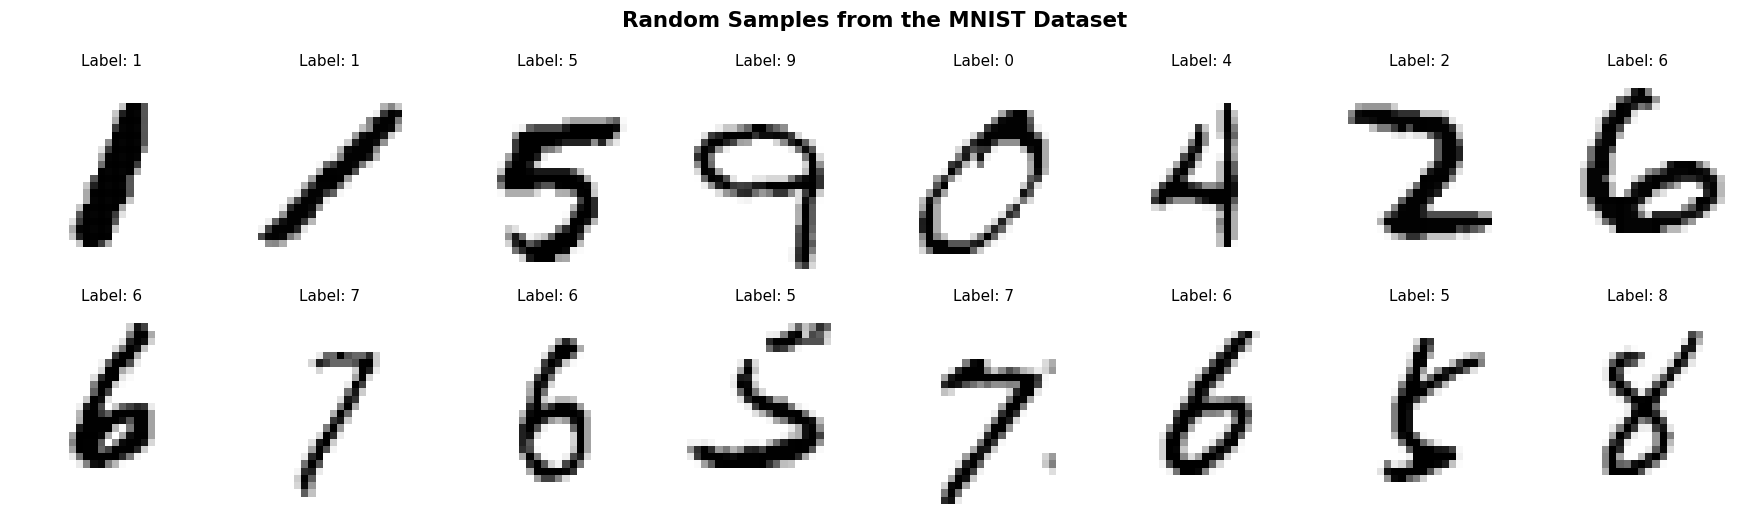

In [4]:
#@title 📊 Let's look at some examples (double-click to view the code) { display-mode: "form" }
# @markdown The images below are random samples from our training set. Each one is a handwritten digit with its true label shown above it.

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle("Random Samples from the MNIST Dataset", fontsize=14, fontweight='bold')

rng = np.random.default_rng(RANDOM_STATE)
indices = rng.integers(0, len(X_train), size=16)
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[indices[i]], cmap='gray_r')
    ax.set_title(f"Label: {y_train[indices[i]]}", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 🤖 Part 2: Building and Training the Autoencoder

### The Analogy Continued

Now we hire our compression team:
- **The Encoder** squeezes a 28×28 image (784 numbers) down to just **16 numbers**, the "summary".
- **The Decoder** takes those 16 numbers and tries to reconstruct the full 28×28 image.

That is a compression ratio of 49 to 1. Sixteen numbers is *not* enough to memorise a
handwritten digit, and that is the point: the encoder has to spend them on whatever
matters most for redrawing the image, and throw the rest away.

The network is trained by comparing its output to the original input and adjusting itself to minimize the difference. No labels needed!

> 🧩 **Key concept:** The 16-number summary is called the **latent representation** or **latent space**. It's like a compressed fingerprint of the image.

The architecture below defines our autoencoder using convolutional layers, a type of layer that's particularly good at processing images.

In [5]:
#@title 🧩 Visualization: the shape of the network (double-click to view the code) { display-mode: "form" }
import uuid
from IPython.display import HTML, display

_UID = uuid.uuid4().hex[:8]

# Bar height shows the picture's resolution at each step. The bottleneck is not a
# picture at all, so it gets a shape of its own: sixteen numbers.
_ENCODER = [("28x28", "the image", 100), ("14x14", "conv 1", 74),
            ("7x7", "conv 2", 52), ("4x4", "conv 3 + pool", 34)]
_DECODER = [("7x7", "reshape", 52), ("14x14", "deconv 1", 74),
            ("28x28", "deconv 2", 100)]


def _bar(size, label, h, c1, c2):
    return f'''
    <div style="display:flex; flex-direction:column; align-items:center;
                justify-content:flex-end; min-width:62px; flex:0 0 auto;">
      <div style="width:34px; height:{h}px; border-radius:7px;
                  background:linear-gradient(180deg,{c1},{c2});"></div>
      <div style="font-weight:650; color:#23262f; font-size:.78rem; margin-top:7px;">{size}</div>
      <div style="color:#6b7280; font-size:.68rem;">{label}</div>
    </div>'''


_ARROW = ('<div style="color:#b9bdc9; font-size:1.25rem; align-self:center;'
          ' flex:0 0 auto; padding:0 2px;">&rsaquo;</div>')

_dots = "".join(
    '<div style="width:9px; height:9px; border-radius:50%; background:#fff;'
    ' opacity:.92;"></div>' for _ in range(16))

_enc = _ARROW.join(_bar(s, l, h, "#667eea", "#764ba2") for s, l, h in _ENCODER)
_dec = _ARROW.join(_bar(s, l, h, "#e0a23c", "#39b36a") for s, l, h in _DECODER)

_html = f'''
<style>
  @keyframes pulse{_UID} {{
    0%, 100% {{ box-shadow: 0 0 0 0 rgba(118,75,162,.42); }}
    50%      {{ box-shadow: 0 0 0 13px rgba(118,75,162,0); }}
  }}
  .neck{_UID} {{ animation: pulse{_UID} 2.6s ease-out infinite; }}
</style>
<div style="font-family: system-ui, Segoe UI, Roboto, sans-serif;
            border-radius:18px; border:1px solid #ecebff; padding:18px;
            background:linear-gradient(135deg,#f6f8ff,#fbf5ff);">
  <div style="font-size:.78rem; letter-spacing:.14em; text-transform:uppercase;
              color:#764ba2; margin-bottom:14px;">
    784 numbers in, 16 in the middle, 784 back out
  </div>
  <div style="display:flex; flex-wrap:wrap; gap:6px; align-items:flex-end;
              justify-content:center;">
    {_enc}
    {_ARROW}
    <div class="neck{_UID}" style="flex:0 0 auto; margin:0 6px; padding:11px 13px;
                border-radius:14px; text-align:center;
                background:linear-gradient(135deg,#764ba2,#e0796d);">
      <div style="display:grid; grid-template-columns:repeat(4,9px); gap:4px;">{_dots}</div>
      <div style="color:#fff; font-weight:700; font-size:.78rem; margin-top:8px;">16</div>
      <div style="color:#f3ecff; font-size:.66rem;">the summary</div>
    </div>
    {_ARROW}
    {_dec}
  </div>
  <div style="display:flex; flex-wrap:wrap; gap:10px; margin-top:16px;">
    <div style="flex:1 1 240px; background:#fff; border:1px solid #e6e8ee;
                border-radius:14px; padding:12px 14px;">
      <div style="font-weight:650; color:#667eea; font-size:.82rem;">ENCODER</div>
      <div style="color:#41465a; font-size:.8rem; margin-top:4px;">
        Shrinks the picture step by step, then writes down what is left as 16
        numbers. Anything it does not keep is gone for good.
      </div>
    </div>
    <div style="flex:1 1 240px; background:#fff; border:1px solid #e6e8ee;
                border-radius:14px; padding:12px 14px;">
      <div style="font-weight:650; color:#39b36a; font-size:.82rem;">DECODER</div>
      <div style="color:#41465a; font-size:.8rem; margin-top:4px;">
        Sees only those 16 numbers, never the original, and has to put all 784
        pixels back.
      </div>
    </div>
  </div>
</div>'''

display(HTML(_html))

In [6]:
#@title 🎯 Understanding Check: Which type of learning? { display-mode: "form" }
# @markdown Autoencoders learn a latent representation on their own, without needing any labels. Which type of ML is this?
answer = "Unsupervised learning" # @param ["Supervised learning", "Unsupervised learning", "Reinforcement learning", "Transformers"]

if answer == "Unsupervised learning":
    print("✅ Correct! Autoencoders are Unsupervised. They use the input data as their own 'target' to learn compressed representations.")
elif answer == "Supervised learning":
    print("❌ Not quite. Supervised learning requires explicit labels (like 'Cat' or 'Dog'). Autoencoders work with unlabeled data.")
elif answer == "Reinforcement learning":
    print("❌ Incorrect. Reinforcement learning is based on rewards and penalties. Autoencoders simply try to reconstruct their input.")
elif answer == "Transformers":
    print("❌ That's an architecture, not a learning paradigm! While Transformers can be trained using unsupervised methods, the category here is Unsupervised Learning.")

✅ Correct! Autoencoders are Unsupervised. They use the input data as their own 'target' to learn compressed representations.


---
### 🎯 TODO 1: Complete `encode()`, `decode()`, and `forward()`

In the cell below, we are declaring the architecture of our autoencoder `class ConvAutoencoder`. Again, an autoencoder is a special type of neural network, so if you remember something from the previous weekend about how to build neural networks in PyTorch, this is gonna feel very familiar!

In `__init__` we have defined the architecture of our autoencoder. Your task is to fill in these methods (functions) inside the class. Each thing you have to write is marked with a blank, `___`.

**`encode(self, x)`**: the encoder forward pass. Chain these steps in order:
1. Apply `self.encoder_conv` (the convolutional layers)
2. Apply `self.encoder_pool` (the pooling layer)
3. Flatten the result with `.flatten(1)`
4. Apply `self.encoder_fc` and return the result

**`decode(self, z)`**: the decoder forward pass:
1. Apply `self.decoder_fc`
2. Reshape the output to `(-1, 64, 7, 7)` using `.view(...)`
3. Apply `self.decoder_conv` and return the result

**`forward(self, x)`**: the full autoencoder pass (one line):
- Encode `x`, then decode the result

> **Hint:** Look at `__init__` to see what each layer does. The comments show the shape at each step.

Once you've filled them in, run the cell below to create the model.

In [10]:
# ============================================================
# 🎯 TODO 1: encode(), decode() and forward()
# ============================================================

class ConvAutoencoder(nn.Module):
    """
    Convolutional Autoencoder for MNIST.
    Encoder: (1, 28, 28) → 16-dim latent vector
    Decoder: 16-dim latent vector → (1, 28, 28)
    """
    def __init__(self):
        super().__init__()

        # ── ENCODER ───────────────────────────────────────────────────────────
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),   # → (16, 14, 14)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),  # → (32,  7,  7)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # → (64,  7,  7)
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
        )
        # AdaptiveAvgPool guarantees 4×4 output regardless of minor size differences
        self.encoder_pool = nn.AdaptiveAvgPool2d((4, 4))             # → (64,  4,  4)
        self.encoder_fc   = nn.Linear(64 * 4 * 4, 16)               # → 16   (no activation!)

        # ── DECODER ───────────────────────────────────────────────────────────
        self.decoder_fc   = nn.Sequential(
            nn.Linear(16, 64 * 7 * 7),
            nn.LeakyReLU(0.1),
        )
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1),  # → (32, 7, 7)
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # → (16, 14, 14)
            nn.BatchNorm2d(16),
            nn.LeakyReLU(0.1),
            nn.ConvTranspose2d(16,  1, kernel_size=4, stride=2, padding=1),  # → (1, 28, 28)
            nn.Sigmoid(),   # output in [0, 1] to match normalised pixel values
        )

    def encode(self, x):
        # 🎯 COMPLETE THESE FOUR LINES:
        x = self.encoder_conv(x)
        x = self.encoder_pool(x)
        x = x.flatten(1)
        return self.encoder_fc(x)

    def decode(self, z):
        # 🎯 COMPLETE THESE THREE LINES:
        x = self.decoder_fc(z)
        x = x.view(-1, 64, 7, 7)
        return self.decoder_conv(x)

    def forward(self, x):
        # 🎯 COMPLETE THIS LINE: encode x, then decode the result.
        return self.decode(self.encode(x))

In [11]:
set_seed(RANDOM_STATE)      # same starting weights for everybody

autoencoder = ConvAutoencoder().to(DEVICE)
total_params = sum(p.numel() for p in autoencoder.parameters())
print(f"✅ Autoencoder created with {total_params:,} trainable parameters")
print(f"   Input  : 1×28×28 = 784 values")
print(f"   Latent : 16 values    (compression ratio: {784/16:.0f}×)")
print(f"   Output : 1×28×28 = 784 values")

✅ Autoencoder created with 120,257 trainable parameters
   Input  : 1×28×28 = 784 values
   Latent : 16 values    (compression ratio: 49×)
   Output : 1×28×28 = 784 values


In [12]:
# Check TODO 1. Four PASS lines, on an untrained model, in about a second.
check_autoencoder_shapes(autoencoder)

PASS     encode() turns 4 images into 4 latent vectors of 16 numbers
PASS     decode() turns those back into 4 images of 1x28x28
PASS     forward() gives back something the same shape as its input
PASS     the output pixels are in [0, 1], like the input


True

---
### Training the Autoencoder

We implemented a standard neural network training loop in the `train_autoencoder()` function. However, the core gradient update step has been left for you to complete.

---
### 🎯 TODO 2: Complete the training step

In the `train_autoencoder()` function below you'll find the inner training loop. You'll see three lines with blanks marked `___`. Fill them in using the variables already available:

- `model`: the autoencoder
- `xb`: the input batch
- `yb`: the target batch (clean images)
- `loss_fn`: `nn.MSELoss()`
- `opt`: the Adam optimizer

The three steps are:
1. Compute the loss: pass `xb` through the model and compare the output to `yb` using the `loss_fn`. Store it in a variable called `loss`, because the line that adds up the epoch total reads that name.
2. Backpropagate: call `.backward()` on the loss
3. Update the weights: call `.step()` on the optimizer

> **Note:** `opt.zero_grad()` and gradient clipping are already handled for you.
> Steps 1 and 2 go **above** the clipping line and step 3 **below** it, because clipping
> only has an effect if it runs after `.backward()` and before `.step()`.

In [17]:
# ============================================================
# 🎯 TODO 2: the training step
# ============================================================

def train_autoencoder(model, X_train_np, X_input_np=None, epochs=25, batch_size=128, lr=2e-3):
    """
    Train an autoencoder.
      X_train_np : TARGET images (what we want the output to look like)
      X_input_np : INPUT  images (what we feed in; defaults to X_train_np)
    For a denoising autoencoder, pass noisy images as X_input_np and clean as X_train_np.
    """
    if X_input_np is None:
        X_input_np = X_train_np

    X_in  = torch.tensor(X_input_np[:, None, :, :]).to(DEVICE)
    X_tgt = torch.tensor(X_train_np[:, None, :, :]).to(DEVICE)
    loader = DataLoader(TensorDataset(X_in, X_tgt), batch_size=batch_size, shuffle=True)

    opt     = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # Cosine LR schedule: gently decays learning rate over training
    sched   = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.MSELoss()
    model.train()

    for epoch in range(1, epochs + 1):
        total = 0
        epoch_lr = sched.get_last_lr()[0]     # the rate this epoch actually runs at
        for xb, yb in loader:
            opt.zero_grad()
            # 🎯 COMPLETE THESE TWO LINES, steps 1 and 2:
            loss = loss_fn(model(xb), yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # keep as is

            # 🎯 COMPLETE THIS LINE, step 3:
            opt.step()

            total += loss.item() * len(xb)
        sched.step()
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{epochs} - Loss: {total/len(X_in):.5f}  (lr={epoch_lr:.5f})")

    print("✅ Training complete!")
    return model

In [18]:
# Check TODO 2. Trains a throwaway copy on 512 images for 3 epochs, which takes
# a few seconds, rather than letting a broken loop waste the full training run.
check_training_step(train_autoencoder, ConvAutoencoder, X_train)

PASS     the optimizer actually updated the weights
PASS     three epochs on 512 images brought the loss down


True

Both lines PASS? Then run the cell below to start the real training. This will take a few minutes ☕

In [19]:
set_seed(RANDOM_STATE)      # same batch order for everybody

print("Training Classic Autoencoder (clean images → clean images)...")
autoencoder = train_autoencoder(autoencoder, X_train_np=X_train, epochs=25)

Training Classic Autoencoder (clean images → clean images)...
  Epoch   1/25 - Loss: 0.03020  (lr=0.00200)
  Epoch   5/25 - Loss: 0.00860  (lr=0.00188)
  Epoch  10/25 - Loss: 0.00754  (lr=0.00143)
  Epoch  15/25 - Loss: 0.00677  (lr=0.00081)
  Epoch  20/25 - Loss: 0.00608  (lr=0.00027)
  Epoch  25/25 - Loss: 0.00568  (lr=0.00001)
✅ Training complete!


---
### 🔍 How Well Does It Reconstruct?

Before we can visualise reconstructions, we need a function to run images through the model at inference time. This is slightly different from training, because we need to tell PyTorch we're not computing gradients.

---
### 🎯 TODO 3: Complete `reconstruct()`

Below you'll find the `reconstruct()` function. Fill in the blanks:

1. Set the model to evaluation mode with `model.eval()`
2. Wrap your code in a `torch.no_grad()` context manager (this disables gradient tracking)
3. Inside it:
   - Convert `X_np` to a torch tensor, add a channel dimension (`[:, None, :, :]`), move to `DEVICE`
   - Pass it through `model(...)`
   - Store the result in `out`
4. Return `out.cpu().numpy()[:, 0, :, :]` (moves back to CPU and removes the channel dim)

> **Why `model.eval()`?** It disables dropout and sets BatchNorm to use running statistics, which matters for consistent inference results.

Once done, run the cell below.

In [20]:
#@title 💭 Need an extra hint? (double-click to view the code) { display-mode: "form" }
# @markdown Click on "show code" to have some help with converting `X_np` to a tensor and adding the extra dimension

# HINT, this is the conversion you need inside reconstruct().
# It is written as a comment on purpose: read it, don't run it.
#
#     X_np_as_tensor = torch.tensor(X_np[:, None, :, :])
#
# The [:, None, :, :] part inserts the channel dimension the model expects:
#     (N, 28, 28)  ->  (N, 1, 28, 28)

In [22]:
# ============================================================
# 🎯 TODO 3: inference
# ============================================================

def reconstruct(model, X_np):
    """Run images through the autoencoder, return reconstructions as numpy arrays."""
    # 🎯 COMPLETE THESE FOUR LINES:
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X_np[:, None, :, :]).to(DEVICE))
    return out.cpu().numpy()[:, 0, :, :]

In [23]:
# Check TODO 3. Three PASS lines.
check_reconstruct(reconstruct, autoencoder, X_test)

PASS     reconstruct() returns a numpy array
PASS     it has one 28x28 image per input image
PASS     the pixels are in [0, 1]


True

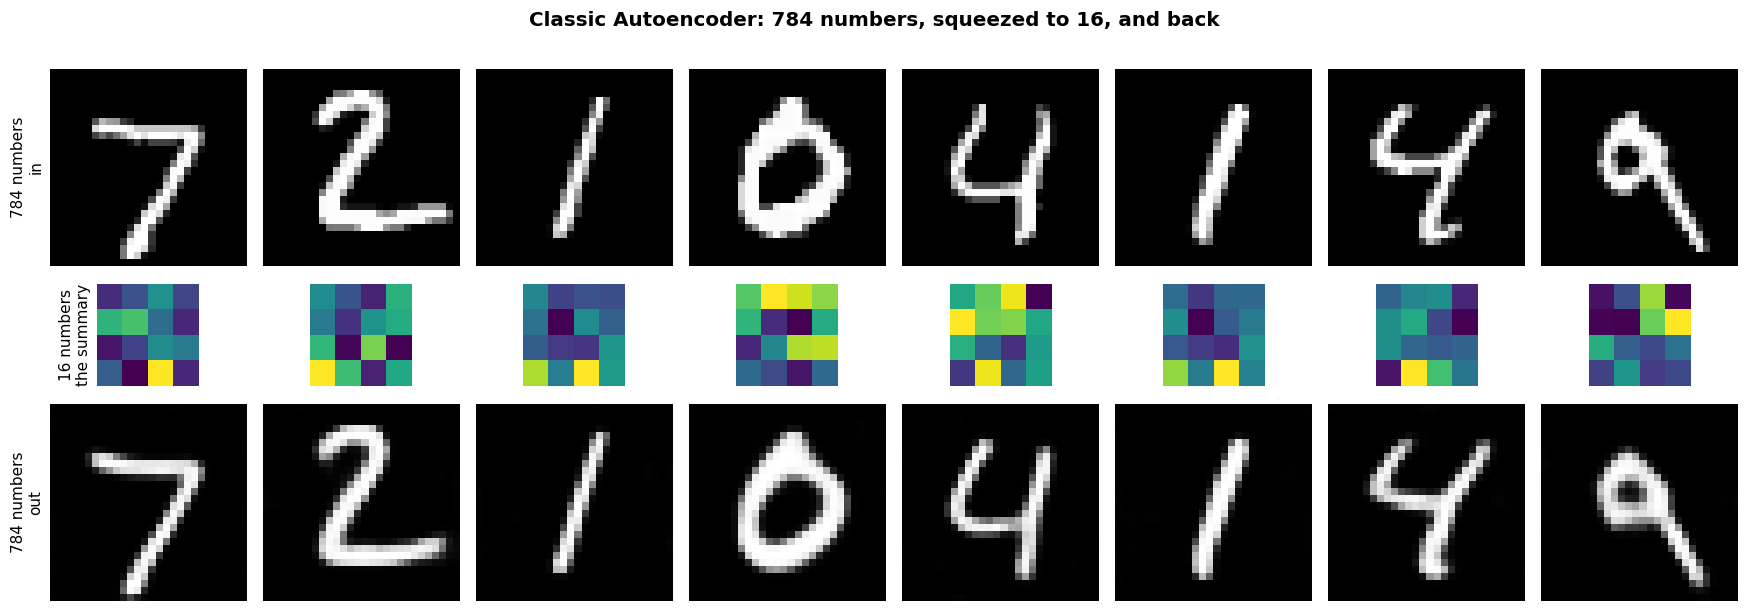

In [24]:
recon_classic = reconstruct(autoencoder, X_test)

# The summary itself, shown between what went in and what came back out.
autoencoder.eval()
with torch.no_grad():
    latent_test = autoencoder.encode(
        torch.tensor(X_test[:8, None, :, :]).to(DEVICE)).cpu().numpy()

plot_compression_triplet(X_test, latent_test, recon_classic, n=8,
                         title="Classic Autoencoder: 784 numbers, squeezed to 16, and back")

The middle row is the whole message. Sixteen numbers per image is everything that
crosses the network, and the bottom row is what the decoder rebuilt from them, having
never seen the original.

Should look pretty good! But how good?

---
### 📊 Measuring Quality with a Digit Classifier

Looking at images is subjective. To measure quality more rigorously, we train a simple digit classifier on *clean* images, and then ask it to classify the *reconstructed* images. If the reconstructions are good, the classifier should still recognise the digits correctly.

> **Think of it this way:** after our compressor-reconstructor team processes a document, we ask a human reader to see if they can still understand the content. Their comprehension rate is our quality metric.

Training digit classifier on clean images (this takes ~1 min)...

Evaluating on RECONSTRUCTED test images:
  Accuracy: 98.25%


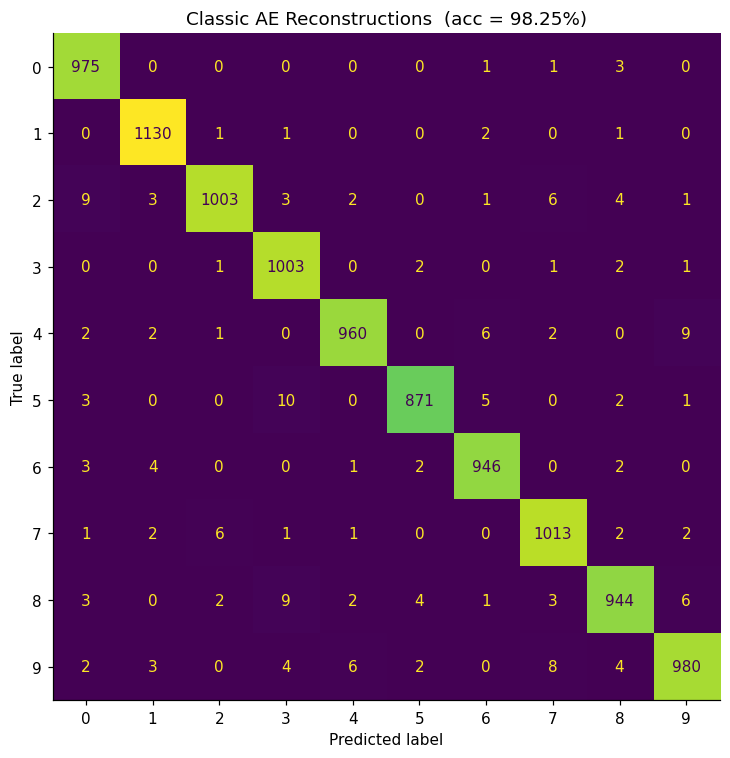

In [25]:
#@title 📊 Train the classifier and score the reconstructions (double-click to view the code) { display-mode: "form" }
set_seed(RANDOM_STATE)

print("Training digit classifier on clean images (this takes ~1 min)...")
classifier = train_classifier(MNISTClassifier, X_train, y_train)

print("\nEvaluating on RECONSTRUCTED test images:")
acc_classic = evaluate_and_plot_confusion(classifier, recon_classic, y_test,
                                           title="Classic AE Reconstructions")

### 💡 How to Read the Confusion Matrix

Each row is the digit the image really was, each column is what the reader thought it was, so the diagonal is everything it got right and everything off the diagonal is a mistake.

The mistakes are not scattered at random. They pile up in a few cells, usually on pairs like 4 and 9, 3 and 8, or 5 and 8, and hardly ever on a pair like 0 and 1. That is the single most useful habit to take from this grid: an accuracy of "about 95 percent" is one number, and the matrix tells you *which* five percent it is. A compression pipeline that loses a few 4s to 9s is a very different proposition from one that loses them uniformly, and only one of those two facts survives into the headline.

Keep those pairs in mind. They come back in Part 3, where you will find the same digits sitting next to each other in the latent space, for the same reason.

---
## Exploring Reconstruction Quality Per Digit

### Context

Now we measure the compression itself, digit by digit: how much of each original did we actually lose? Some classes cost the autoencoder far more than others, and knowing *which ones* is valuable.

**Why does this matter in business?**
Imagine you're using an autoencoder to compress medical scan images before transmitting them over the network. If the autoencoder reconstructs certain types of scans poorly, that's a critical issue, even if the average quality is high.

---

In [ ]:
#@title 📊 Reconstruction quality statistics per digit (double-click to view the code) { display-mode: "form" }
digit_mse = {}
for d in range(10):
    mask  = (y_test == d)
    orig  = X_test[mask]
    recon = recon_classic[mask]
    digit_mse[d] = np.mean((orig - recon)**2)

print("Average reconstruction MSE per digit:")
for d, mse in digit_mse.items():
    print(f"  Digit {d}: {mse:.5f}")

# Bar chart
worst_digit = max(digit_mse, key=digit_mse.get)
fig, ax = plt.subplots(figsize=(10, 4))
colors = [RED if d == worst_digit else PURPLE for d in digit_mse]
ax.bar(list(digit_mse.keys()), list(digit_mse.values()), color=colors, edgecolor='black')
ax.set_xlabel("Digit", fontsize=12)
ax.set_ylabel("Average MSE", fontsize=12)
ax.set_title("Reconstruction Error per Digit Class (red = worst)", fontsize=13, fontweight='bold')
ax.set_xticks(range(10))
plt.tight_layout(); plt.show()

# Worst digit
print(f"\nWorst reconstructed digit: {worst_digit}")

mask_worst  = (y_test == worst_digit)
orig_worst  = X_test[mask_worst][:5]
recon_worst = recon_classic[mask_worst][:5]
plot_reconstruction_error(orig_worst, recon_worst, n=5,
                          title=f"Digit {worst_digit}: where the error actually is")

### 💬 Debrief

Think about what you found:
- Which digit has the highest reconstruction error? Does this make intuitive sense given what that digit looks like? Is the error much higher?
- The digits 3, 5, and 8 often have the highest errors, because they share curved strokes that are hard to distinguish in a compressed representation.
- The error row is worth a second look. The loss is not spread evenly over the image: it traces the strokes and burns brightest on the loops and the joins, exactly where one writer's 8 differs from another's. That is the detail 16 numbers could not afford to keep.
- **Business takeaway:** Average metrics hide per-class weaknesses. Always investigate disaggregated performance before deploying a model.

---
## 🌐 Part 3: Visualizing the Latent Space

### What Does the "Summary" Look Like?

Remember our 16-number bottleneck? Each image gets mapped to a point in this 16-dimensional space. We can't visualise 16 dimensions, but we can use **PCA** to project it down to 2D.

**What should we expect?** If the autoencoder learned meaningful features, images of the same digit should cluster together. The "1" images should be near each other, and far from "8" images, and this should show in the compressed representation.

In [ ]:
#@title 📊 Latent space visualization (double-click to view the code) { display-mode: "form" }
# ── Step 1: Extract latent vectors for a subset of test images ───────────────
N_VIZ = 2000
autoencoder.eval()
with torch.no_grad():
    latent_all = autoencoder.encode(
        torch.tensor(X_test[:N_VIZ, None, :, :]).to(DEVICE)
    ).cpu().numpy()

labels_viz = y_test[:N_VIZ]

# Project to 2D with PCA
pca_viz  = PCA(n_components=2, random_state=RANDOM_STATE)
lat_2d   = pca_viz.fit_transform(latent_all)
var_exp  = pca_viz.explained_variance_ratio_.sum()
print(f"2D PCA explains {var_exp:.1%} of latent variance")

# ── Step 2: Build decoder grid ────────────────────────────────────────────────
GRID = 14
x_range = np.linspace(lat_2d[:, 0].min() * 0.9, lat_2d[:, 0].max() * 0.9, GRID)
y_range = np.linspace(lat_2d[:, 1].max() * 0.9, lat_2d[:, 1].min() * 0.9, GRID)

grid_points_2d = np.array([[x, y] for y in y_range for x in x_range], dtype="float32")
grid_latent = pca_viz.inverse_transform(grid_points_2d)
with torch.no_grad():
    grid_images = autoencoder.decode(
        torch.tensor(grid_latent).to(DEVICE)
    ).cpu().numpy()[:, 0, :, :]

canvas_h = GRID * 28
canvas_w = GRID * 28
decoder_canvas = np.zeros((canvas_h, canvas_w))
for idx, img in enumerate(grid_images):
    r, c = divmod(idx, GRID)
    decoder_canvas[r*28:(r+1)*28, c*28:(c+1)*28] = img

# ── Step 3: Side-by-side plot ────────────────────────────────────────────────
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
fig, (ax_enc, ax_dec) = plt.subplots(1, 2, figsize=(16, 7))

for d in range(10):
    mask = labels_viz == d
    for x, y in zip(lat_2d[mask, 0][:40], lat_2d[mask, 1][:40]):
        ax_enc.text(x, y, str(d), fontsize=7, color=COLORS[d],
                    ha='center', va='center', fontweight='bold', alpha=0.8)
# Automatically scale the limits based on the data
ax_enc.set_xlim(lat_2d[:, 0].min() * 1.1, lat_2d[:, 0].max() * 1.1)
ax_enc.set_ylim(lat_2d[:, 1].min() * 1.1, lat_2d[:, 1].max() * 1.1)
ax_enc.set_xlabel("PCA₁  (Z₁)", fontsize=11); ax_enc.set_ylabel("PCA₂  (Z₂)", fontsize=11)
ax_enc.set_title("ENCODER MAP (each point = one test image)", fontsize=12, fontweight='bold')

ax_dec.imshow(decoder_canvas, cmap='gray', origin='upper',
              extent=[x_range[0], x_range[-1], y_range[-1], y_range[0]], aspect='auto')
ax_dec.set_xlabel("PCA₁  (Z₁)", fontsize=11); ax_dec.set_ylabel("PCA₂  (Z₂)", fontsize=11)
ax_dec.set_title("DECODER GRID", fontsize=12, fontweight='bold')

plt.suptitle("Latent Space Visualisation", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### 💡 How to Read This Plot

**Left, the Encoder Map:** Each digit label represents one test image, positioned according to where the autoencoder *compressed* it in latent space. Same digits cluster together, and nothing in training ever told the network which digit was which.

**Right, the Decoder Grid:** We systematically sweep across the 2D latent space and *decode* each point back to an image. The grid shows what the autoencoder would generate at each location. Notice how digits transition smoothly, with no sharp edges, just gradual morphing. This is the continuous structure the autoencoder has learned.

### Who ends up next to whom

The interesting part is not that the classes separate. It is *which* ones sit on top of each other. Look for these neighbours on the left-hand map, and expect the exact arrangement to shift a little from run to run:

- **1 and 7** sit close together. Both are essentially a single stroke, and once the little horizontal bar has been compressed away there is not much left to tell them apart.
- **5 and 8** sit close, and so do **3 and 8**. All three are built from stacked curves, and the difference is whether a curve closes.
- **2 and 3** share the top arc and differ mainly in what happens underneath it.
- **4 and 9** differ by whether the loop at the top is closed. That is a handful of pixels, and a handful of pixels is exactly what a bottleneck spends first.

None of this was designed. The encoder was never shown a label; it arranged the space this way because those digits genuinely *are* similar once you are only allowed 16 numbers to describe them. Compare the list against the per-digit errors from Part 2 and the off-diagonal cells of the confusion matrix: they tend to agree, because all three are measuring the same thing, which is where the budget ran out.

**Business takeaway:** Before deploying an autoencoder as an anomaly detector, map your latent space and find out what already sits close together. Those neighbourhoods are where your false alarms will come from, and it is much cheaper to learn that here than from the people who have to triage the alerts.

---
## 🌧️ Part 4: What Happens with Noisy Input?

In practice, data is rarely clean. Medical scans have artifacts. Financial records have entry errors. Sensor data has interference. What happens when we feed our autoencoder corrupted input?

---
### 🎯 TODO 4: Generate noisy images using `add_noise()`

The `add_noise()` function is in the cell right below. The Gaussian noise is already generated for you as `unscaled_noise`, so fill in the last two steps:

1. Multiply `unscaled_noise` by `noise_factor` and add it to `X`
2. Clip the result to `[0, 1]` with `np.clip(..., 0, 1)` and return it as `float32`

Once done, run the cell below.

In [ ]:
# ============================================================
# 🎯 TODO 4: add_noise()
# ============================================================

def add_noise(X, noise_factor=0.3, seed=None):
    """
    Adds Gaussian noise to images and clips the result to [0, 1].

    Parameters
    ----------
    X            : numpy array of shape (N, 28, 28)
    noise_factor : standard deviation of the noise
    seed         : optional random seed for reproducibility

    Returns
    -------
    Noisy images as float32 array, same shape as X.
    """
    rng = np.random.default_rng(seed)
    unscaled_noise = rng.standard_normal(X.shape).astype("float32")
    # 🎯 COMPLETE THESE TWO LINES:
    noisy = X + ___ * ___
    return np.clip(___, 0, 1).astype("float32")

In [ ]:
# Check TODO 4. Six PASS lines.
check_add_noise(add_noise, X_train)

In [ ]:
#@title 📊 Clean images and the version with added noise (double-click to view the code) { display-mode: "form" }
# Different seeds for train and test, so the test images are corrupted by a
# draw the model never trained against.
X_train_noisy = add_noise(X_train, noise_factor=0.3, seed=RANDOM_STATE)
X_test_noisy  = add_noise(X_test,  noise_factor=0.3, seed=RANDOM_STATE + 1)

plot_image_pair(X_test, X_test_noisy, n=8,
                title="Clean vs. Noisy Images",
                row_labels=("Clean", "Noisy"))

### Feeding Noisy Images to the Classic Autoencoder

The classic autoencoder was trained only on clean images. What will it do with noisy input?

In [ ]:
#@title 📊 How does our classic Autoencoder do on noisy input? (double-click to view the code) { display-mode: "form" }
recon_noisy_classic = reconstruct(autoencoder, X_test_noisy)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle("Classic AE on Noisy Input", fontsize=13, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test_noisy[i],        cmap='gray')
    axes[1, i].imshow(recon_noisy_classic[i], cmap='gray')
    axes[2, i].imshow(X_test[i],              cmap='gray')
style_image_grid(axes, ["Noisy Input", "AE Output", "Ground Truth"])
plt.tight_layout(); plt.show()

acc_noisy_classic = (predict_digits(classifier, recon_noisy_classic) == y_test).mean()
print(f"Classifier accuracy on classic AE outputs (noisy input): {acc_noisy_classic:.2%}")

### 📉 As Expected: It Struggles

The classic autoencoder was trained to compress-and-reconstruct clean images. When faced with noisy input, the noise gets "baked in" to the reconstruction.

**The fix:** Train the autoencoder *specifically* to remove noise, by feeding it noisy images as input and asking it to output clean images. This is called a **Denoising Autoencoder**.

---
## 🧹 Part 5: The Denoising Autoencoder

### A Smarter Compression Team

Instead of clean → clean, we train on **noisy → clean**. Same architecture, different training objective: *learn to remove the noise*.

> **Business Analogy:** This is like training a document processing team specifically on garbled faxes, so they learn to infer the intent even when the input is messy.

---
### 🎯 TODO 5: Train the Denoising Autoencoder

`train_autoencoder()` accepts two image arrays:
- `X_train_np`: the **target** (what the output should look like)
- `X_input_np`: the **input** (what we feed in)

For the classic AE we passed clean images to both. For the denoising AE, pass:
- the clean targets, `X_train`
- the noisy inputs, `X_train_noisy`

Assign the two arrays below. Get them the wrong way round and you train a model that *adds* noise, which looks entirely plausible for twenty epochs, so the check cell tests them before any training starts.

In [ ]:
# ============================================================
# 🎯 TODO 5: clean target, noisy input
# ============================================================

# 🎯 COMPLETE THESE TWO LINES, using X_train and X_train_noisy:
DAE_TARGET = ___   # the target: what the output should look like
DAE_INPUT  = ___   # the input:  what we feed in

In [ ]:
# Check TODO 5. Two PASS lines, before twenty epochs of training, not after.
check_denoising_pair(DAE_TARGET, DAE_INPUT, X_train, X_train_noisy)

In [ ]:
set_seed(RANDOM_STATE)

denoising_ae = ConvAutoencoder().to(DEVICE)
print("Training Denoising Autoencoder (input=noisy, target=clean)...")
denoising_ae = train_autoencoder(
    model=denoising_ae,
    X_train_np=DAE_TARGET,
    X_input_np=DAE_INPUT,
    epochs=20
)

In [ ]:
#@title 📊 How does our denoising Autoencoder do on noisy input? (double-click to view the code) { display-mode: "form" }
recon_denoised = reconstruct(denoising_ae, X_test_noisy)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle("Denoising AE: Noisy → Denoised → Original", fontsize=13, fontweight='bold')
for i in range(8):
    axes[0, i].imshow(X_test_noisy[i],   cmap='gray')
    axes[1, i].imshow(recon_denoised[i], cmap='gray')
    axes[2, i].imshow(X_test[i],         cmap='gray')
style_image_grid(axes, ["Noisy Input", "Denoised", "Ground Truth"])
plt.tight_layout(); plt.show()

acc_denoised = (predict_digits(classifier, recon_denoised) == y_test).mean()
print(f"Classifier accuracy on denoising AE outputs: {acc_denoised:.2%}")

---
## Head-to-Head Comparison

### Context

You've now trained two autoencoders:
1. **Classic AE**: trained on clean images, tested on noisy input (struggles)
2. **Denoising AE**: trained on noisy→clean pairs (handles noise well)

This section brings them together for a structured comparison. In a business setting, this is analogous to a **model evaluation report** before deciding which system to deploy.

---

In [ ]:
#@title 📊 Head-to-head comparison: classic vs denoising AE (double-click to view the code) { display-mode: "form" }
mse_classic  = {d: np.mean((recon_noisy_classic[y_test == d] - X_test[y_test == d])**2) for d in range(10)}
mse_denoised = {d: np.mean((recon_denoised[y_test == d]      - X_test[y_test == d])**2) for d in range(10)}

#Grouped bar chart
x = np.arange(10)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, [mse_classic[d]  for d in range(10)], width, label='Classic AE',   color=RED)
ax.bar(x + width/2, [mse_denoised[d] for d in range(10)], width, label='Denoising AE', color=GREEN)
ax.set_xlabel("Digit"); ax.set_ylabel("Avg MSE (lower = better)")
ax.set_title("Per-Digit Reconstruction Error: Classic vs. Denoising AE", fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.legend(); plt.tight_layout(); plt.show()

#Largest gap
gaps = {d: mse_classic[d] - mse_denoised[d] for d in range(10)}
biggest_gap_digit = max(gaps, key=gaps.get)
print(f"\nLargest improvement on digit: {biggest_gap_digit} (gap = {gaps[biggest_gap_digit]:.5f})")

mask = (y_test == biggest_gap_digit)
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
fig.suptitle(f"Digit {biggest_gap_digit}: Detailed Comparison", fontsize=13, fontweight='bold')
for i in range(5):
    axes[0, i].imshow(X_test_noisy[mask][i],        cmap='gray')
    axes[1, i].imshow(recon_noisy_classic[mask][i], cmap='gray')
    axes[2, i].imshow(recon_denoised[mask][i],      cmap='gray')
    axes[3, i].imshow(X_test[mask][i],              cmap='gray')
style_image_grid(axes, ["Noisy Input", "Classic AE", "Denoising AE", "Ground Truth"])
plt.tight_layout(); plt.show()

### 💬 Debrief

You've just produced a model evaluation report, the kind of analysis that would precede a real deployment decision.

Key observations:
- The denoising AE wins on virtually every digit, usually by a large margin.
- The *relative* improvement varies across digits. Digits with more complex shapes benefit more from denoising.
- **Business takeaway:** Before choosing between models, understand *where* each one fails, not just the overall score. A model that's 95% accurate overall but systematically fails on one critical sub-class may be unacceptable.

---
## 🏢 Part 6: Where Are Autoencoders Used in Business Today?

Autoencoders aren't just an academic exercise. Here are real-world scenarios where the same principles you just explored are being applied at scale:

---

### 1. 🏦 Fraud Detection in Banking

**The challenge:** Banks process millions of transactions per day. Most are normal. A handful are fraudulent, but what does "normal" even look like?

**How autoencoders help:** An autoencoder is trained on *normal* transactions only. It learns to compress and reconstruct normal patterns very well. When a fraudulent transaction arrives, with unusual patterns the model has never seen, the reconstruction error spikes. That spike is the fraud signal. Companies like PayPal and Visa use anomaly detection systems built on this principle.

---

### 2. 🏥 Medical Image Enhancement

**The challenge:** MRI and CT scans are expensive to acquire at high quality. Low-dose or fast scans are cheaper but noisier.

**How autoencoders help:** A denoising autoencoder, just like the one you trained, is trained on pairs of (low-quality, high-quality) medical images. It learns to clean up noisy scans, enabling faster, cheaper imaging without sacrificing diagnostic quality. GE Healthcare and Siemens Healthineers have published work in this space.

---

### 3. 🛒 Recommender Systems & Personalization

**The challenge:** A streaming service has millions of users and thousands of items. Storing and processing every user's full preference history is costly.

**How autoencoders help:** Autoencoders learn a compact latent representation of each user's behaviour. Users close together in latent space have similar tastes, which powers real-time recommendations. Netflix and Spotify have published research on autoencoders for personalisation.

---

### 4. 🏭 Predictive Maintenance in Manufacturing

**The challenge:** Industrial machines generate thousands of sensor readings per second. Failures are rare but costly.

**How autoencoders help:** An autoencoder is trained on normal operating data. Any deviation, a failing bearing or a temperature anomaly, shows up as elevated reconstruction error. Maintenance teams can intervene before a breakdown occurs.

---

> **The common thread:** In all these cases, the autoencoder learns what "normal" looks like, and flags anything that doesn't fit. This is extraordinarily useful where labelled data is scarce or expensive.

---
---

## ⭐ BONUS: PCA Denoising, A Classic Alternative

> **This section is optional.** If you've made it here and want a deeper challenge, read on. Otherwise, feel free to stop, you've already covered all the core concepts!

---

### Background: PCA as a Compressor

Before deep learning, **Principal Component Analysis (PCA)** was the workhorse for dimensionality reduction. Like an autoencoder, PCA compresses data into a lower-dimensional representation, but it does so *linearly*.

| | PCA | Autoencoder |
|---|---|---|
| Compression type | Linear only | Non-linear |
| Training cost | Instant (math formula) | Slow (gradient descent) |
| Flexibility | Limited | Very flexible |
| Interpretability | High | Lower |

PCA can be used for denoising: project noisy images into a lower-dimensional subspace (capturing the signal), then project back. The noise, being random, doesn't align well with the principal components and gets attenuated.

We give PCA **the same budget the autoencoder had**: 16 numbers per image. Same
compression, same task, same test set, so the only thing that differs is whether the
compression is allowed to bend.

The cell then does it **twice**: once with 16 components, and once with 64. You get a
picture of each and a score for each, so you can see what four times the budget buys.
That is the trade-off you would actually be arguing about in a deployment meeting.

---

### 🧑‍💻 Your Task

Implement PCA denoising and compare it against the autoencoder. Fill in the blanks below.

In [ ]:
# ============================================================
# ⭐ BONUS: PCA Denoising
# ============================================================

# Task 1: Flatten images from (N, 28, 28) to (N, 784)
X_train_noisy_flat = X_train_noisy.reshape(len(X_train_noisy), -1)
X_test_noisy_flat  = X_test_noisy.reshape(len(X_test_noisy),   -1)

n_components = 16          # the same budget the autoencoder had
N_COMPONENTS_BIG = 64      # and the same method given four times as much
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)

# 🎯 COMPLETE THESE THREE LINES:
pca.fit(___)                                                 # Task 2: fit on the flattened noisy TRAINING images
recon_pca_flat = pca.inverse_transform(pca.transform(___))   # Task 3: transform, then inverse_transform, the TEST images
recon_pca = np.clip(___, 0, 1).reshape(-1, 28, 28).astype("float32")   # Task 4: what are you clipping?

In [ ]:
# Check the bonus. Three PASS lines.
check_pca_denoising(recon_pca, X_test_noisy, X_test)

In [ ]:
#@title 📊 PCA denoising results and the final comparison (double-click to view the code) { display-mode: "form" }
# Task 5: the second PCA, given four times the budget.
pca_big = PCA(n_components=N_COMPONENTS_BIG, random_state=RANDOM_STATE).fit(X_train_noisy_flat)
recon_pca_big = np.clip(
    pca_big.inverse_transform(pca_big.transform(X_test_noisy_flat)),
    0, 1).reshape(-1, 28, 28).astype("float32")

# Task 6: look at both, then score both.
plot_image_pair(X_test_noisy, recon_pca, n=8,
                title=f"PCA denoising with {n_components} components",
                row_labels=("Noisy input", f"PCA {n_components}"))
plot_image_pair(X_test_noisy, recon_pca_big, n=8,
                title=f"PCA denoising with {N_COMPONENTS_BIG} components",
                row_labels=("Noisy input", f"PCA {N_COMPONENTS_BIG}"))

acc_pca     = (predict_digits(classifier, recon_pca)     == y_test).mean()
acc_pca_big = (predict_digits(classifier, recon_pca_big) == y_test).mean()

# Final comparison. Every row is the same classifier, on the same test set,
# reading whatever that method produced.
rows = [
    ("Classic AE",   "clean input,  16 numbers", acc_classic),
    ("Classic AE",   "noisy input,  16 numbers", acc_noisy_classic),
    ("Denoising AE", "noisy input,  16 numbers", acc_denoised),
    ("PCA",          f"noisy input,  {n_components} numbers", acc_pca),
    ("PCA",          f"noisy input,  {N_COMPONENTS_BIG} numbers", acc_pca_big),
]
width = max(len(m) for m, _, _ in rows)
print()
print("── Readable share of the test set " + "─" * 24)
for method, setting, value in rows:
    print(f"  {method:<{width}}  {setting:<24} {value:>7.2%}")

### 📊 Reflection Questions

After running PCA denoising at a few different component counts:

1. **At the same 16-number budget, how does PCA compare to the denoising autoencoder?** What's the accuracy gap? Now look at the 64-component row: what does four times the budget buy, and would you pay for it?

2. **Why is an autoencoder better at this task?** (Hint: think about linear vs. non-linear compression.)

3. **In what situations might PCA be *preferable* to an autoencoder**, even if slightly less accurate? Think: training time, interpretability, data requirements.

4. **What happens visually at `n_components=8` vs. `n_components=256`?** Change the number in the task cell and run both cells again. Describe the trade-off.

---

## 🎯 Summary

In this notebook, you've explored the full lifecycle of an autoencoder:

| Step | What You Did |
|---|---|
| Data exploration | Understood the dataset and visualised examples |
| 🎯 TODO 1 | Implemented `encode()`, `decode()`, and `forward()` |
| 🎯 TODO 2 | Completed the gradient update step in the training loop |
| 🎯 TODO 3 | Implemented `reconstruct()` for inference |
| Per-digit analysis | Investigated per-digit reconstruction quality |
| Latent space | Visualised the compressed representation |
| 🎯 TODO 4 | Implemented `add_noise()` for corrupted input |
| 🎯 TODO 5 | Configured the denoising autoencoder training call |
| Head-to-head | Produced a structured model comparison |
| Business cases | Connected the concepts to real-world deployments |
| ⭐ BONUS | Compared against classical PCA denoising |

**The key takeaway:** Autoencoders learn structure without labels. They discover what's "normal", what's "similar", and what should be "filtered out", purely from patterns in data.